<a href="https://colab.research.google.com/github/Misnna/MYDAILYWORK/blob/main/FACE_DETECTION_AND_RECOGNITION_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python face-recognition matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=2fc53177b32d692926802a11f3ba1565c8fb0515f274286418305de167d2757b
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


Saving image detect.jpg to image detect.jpg
Uploaded Image: image detect.jpg


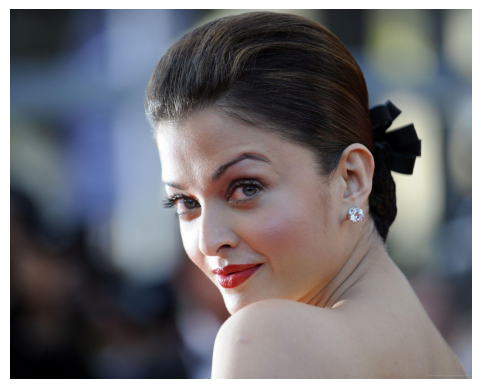

In [2]:
import cv2
import face_recognition
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import numpy as np


uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Uploaded Image:", image_path)

image = face_recognition.load_image_file(image_path)

plt.imshow(image)
plt.axis("off")
plt.show()

Number of faces detected: 1


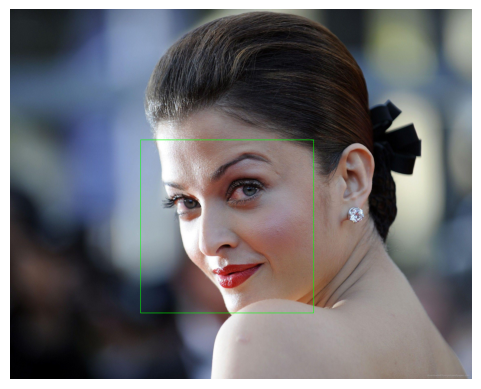

In [4]:
face_locations = face_recognition.face_locations(image)

print("Number of faces detected:", len(face_locations))

image_cv = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

for (top, right, bottom, left) in face_locations:
    cv2.rectangle(image_cv, (left, top), (right, bottom), (0, 255, 0), 2)

image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [8]:
print("Upload a reference image (known person)")
uploaded_known = files.upload()

known_image_path = list(uploaded_known.keys())[0]

known_image = face_recognition.load_image_file(known_image_path)

known_face_encoding = face_recognition.face_encodings(known_image)[0]

known_face_encodings = [known_face_encoding]
known_face_names = ["aishwarya rai"]

print("Reference face stored successfully!")

Upload a reference image (known person)


Saving image detect.jpg to image detect (4).jpg
Reference face stored successfully!


Upload an image to recognize the person


Saving image detect.jpg to image detect (7).jpg


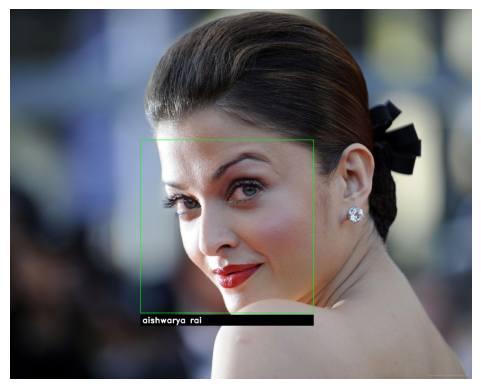

In [11]:
print("Upload an image to recognize the person")
uploaded_test = files.upload()

test_image_path = list(uploaded_test.keys())[0]

test_image = face_recognition.load_image_file(test_image_path)

face_locations = face_recognition.face_locations(test_image)
face_encodings = face_recognition.face_encodings(test_image, face_locations)

test_image_cv = cv2.cvtColor(test_image, cv2.COLOR_RGB2BGR)

for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

    matches = face_recognition.compare_faces(known_face_encodings, face_encoding)

    name = "Unknown"

    if True in matches:
        match_index = matches.index(True)
        name = known_face_names[match_index]

    cv2.rectangle(test_image_cv, (left, top), (right, bottom), (0, 255, 0), 2)

cv2.rectangle(test_image_cv, (left, bottom + 10), (right, bottom + 70), (0, 0, 0), cv2.FILLED)

cv2.putText(
    test_image_cv,
    name,
    (left + 10, bottom + 55),
    cv2.FONT_HERSHEY_DUPLEX,
    1.5,
    (255, 255, 255),
    4
)


test_image_rgb = cv2.cvtColor(test_image_cv, cv2.COLOR_BGR2RGB)

plt.imshow(test_image_rgb)
plt.axis("off")
plt.show()